In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [29]:
df = pd.read_csv('dataset_titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [31]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


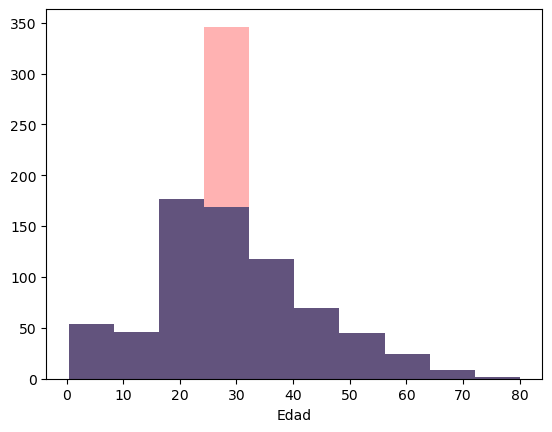

In [32]:
fig, ax = plt.subplots()
ax.hist(df["Age"])
ax.hist(df["Age"].fillna(df["Age"].median()), alpha = 0.3, color = "red")
ax.set_xlabel("Edad")
plt.show()

Resulta evidente que si imputamos todos los valores faltantes con la mediana, la distribución de la edad se verá afectada, ya que se agregará una gran cantidad de datos con el mismo valor: esto se refleja en el histograma. Podemos usar la función ffill, que propaga la última observación.

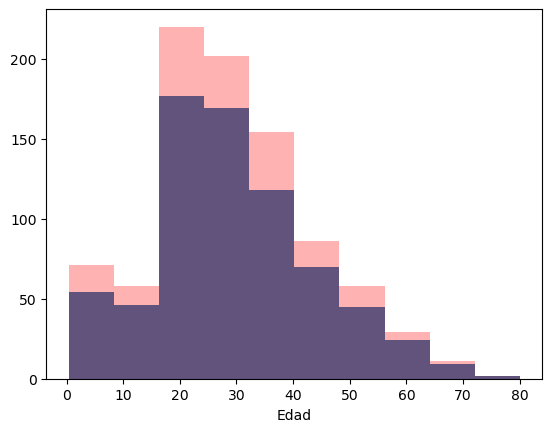

In [33]:
fig, ax = plt.subplots()
ax.hist(df["Age"])
ax.hist(df["Age"].ffill(), alpha = 0.3, color = "red")
ax.set_xlabel("Edad")
plt.show()

O puede también imputarse con un número random entre 0 y 80.

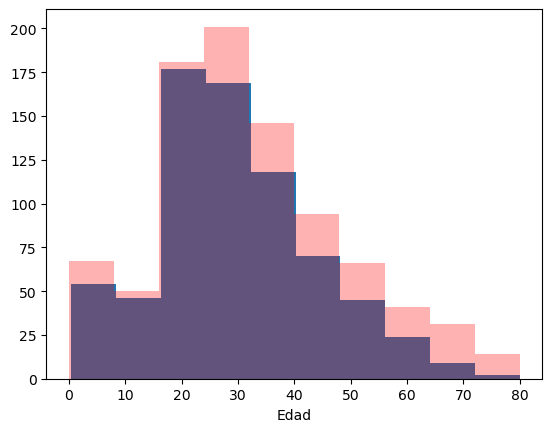

In [34]:
fig, ax = plt.subplots()
ax.hist(df["Age"])
ax.hist(df["Age"].fillna(pd.Series(np.random.randint(0, 80, size=len(df)), index=df.index)), alpha = 0.3, color = "red")
ax.set_xlabel("Edad")
plt.show()

In [35]:
df["Age"] = df["Age"].ffill()

Incluso puedo crear una nueva columna, que sea "age_class" y divida a las personas según su edad en algo más categórico.

In [36]:
def clasificar_edad(edad):
    if edad < 2:
        return "Infante"
    elif edad < 13:
        return "Niño"
    elif edad < 18:
        return "Adolescente"
    elif edad < 30:
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto mayor"

df["age_class"] = df["Age"].apply(clasificar_edad)
df[["Age", "age_class"]].head(10)

,Age,age_class
0,22.0,Joven
1,38.0,Adulto
2,26.0,Joven
3,35.0,Adulto
4,35.0,Adulto
5,35.0,Adulto
6,54.0,Adulto
7,2.0,Niño
8,27.0,Joven
9,14.0,Adolescente


In [37]:
df.groupby("Survived")[["Age", "Pclass", "Fare"]].mean()

,Age,Pclass,Fare
Survived,,,
0,30.33439,2.531876,22.117887
1,28.37307,1.950292,48.395408


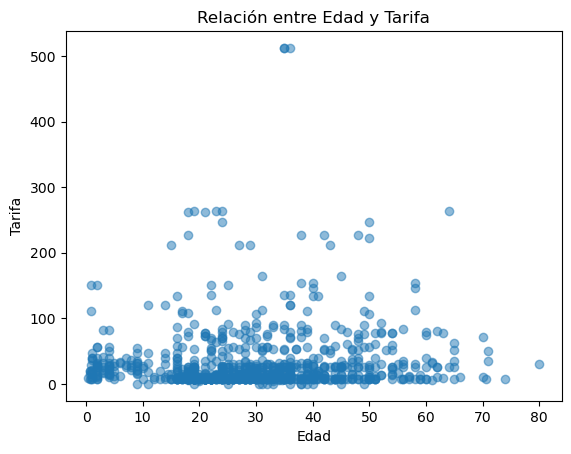

In [39]:
fig,ax = plt.subplots()
plt.scatter(df["Age"], df["Fare"], alpha = 0.5)
ax.set_xlabel("Edad")
ax.set_ylabel("Tarifa")
ax.set_title("Relación entre Edad y Tarifa")
plt.show()

<Axes: xlabel='Sex', ylabel='Fare'>

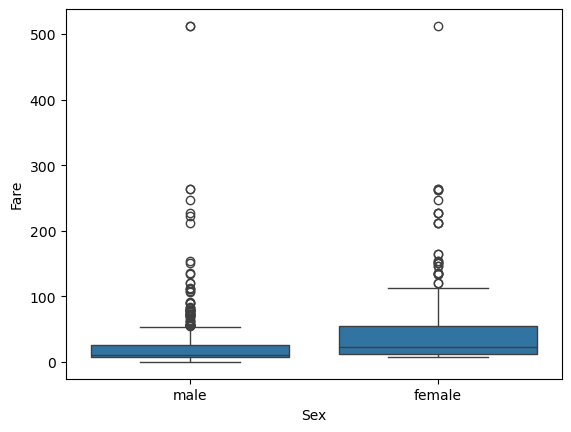

In [42]:
sns.boxplot(x = "Sex", y = "Fare", data = df)

<Axes: xlabel='Survived', ylabel='Age'>

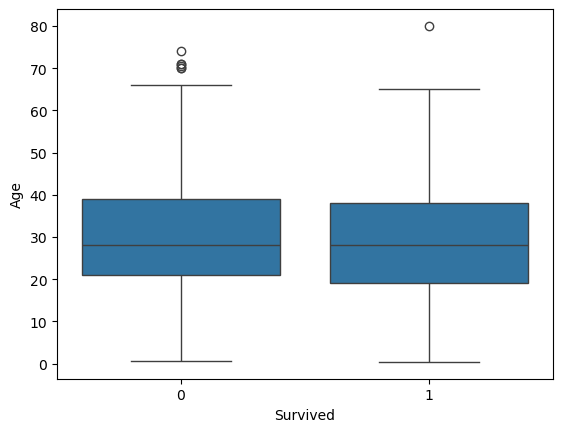

In [43]:
sns.boxplot(x = "Survived", y = "Age", data = df)

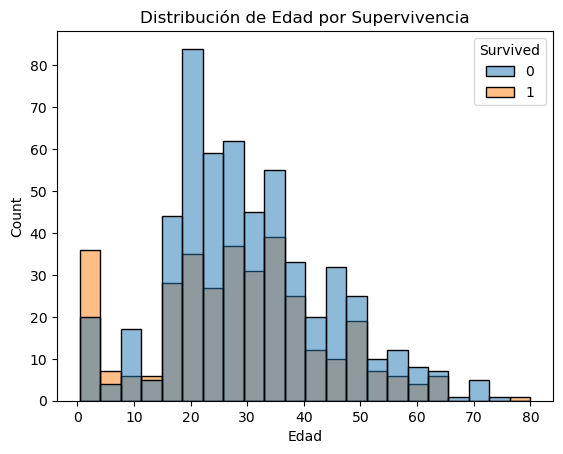

In [46]:
fig, ax = plt.subplots()
sns.histplot(data=df, x="Age", hue="Survived", ax=ax)
ax.set_xlabel("Edad")
ax.set_title("Distribución de Edad por Supervivencia")
plt.show()